### CAPSTONE PROJECT :  Predict Student Dropout Risk

### Step 1: Problem Understanding & Framing

#### 1.1 Problem Statement
> The current educational landscape is characterized by a significant "intervention lag." Despite the wealth of digital student data available, institutions primarily rely on end-of-term results to identify academic failure. This reactive approach results in high attrition rates, leading to substantial institutional revenue loss and diminished student lifetime outcomes. There is a critical need for a reusable, proactive predictive framework that identifies at-risk students while there is still time for meaningful intervention.

#### 1.2 Business & Data Science Problem Framing
> A. The Business Perspective (Institutional Impact)
> * Business Problem: How can an institution optimize its student support services to improve retention rates and protect tuition revenue?
> * Decision Context: Faculty and counselors have limited time; they require a prioritized list of students ranked by "Probability of Attrition."
> * Key Performance Indicators (KPIs): 1.  Retention Rate Uplift: The percentage increase in students remaining enrolled year-over-year.2.  Intervention Lead Time: The number of weeks prior to final exams that a risk flag is generated.3.  Cost-Benefit Ratio: The financial gain from retained tuition versus the cost of intervention and model maintenance.


> B. The Data Science Perspective (Technical Definition)
> * Learning Task: Supervised Binary Classification.
> * Target Variable ($y$): $$y = \begin{cases} 0 & \text{if student drops out} \\ 1 & \text{if student persists} \end{cases}$$
> * Feature Space ($X$): A set of multi-modal features including demographic variables, academic performance trends (time-series), and digital engagement metrics (LMS logs).
> * Optimization Function: Given the high cost of missing a student in need, the model will be optimized to maximize the Area Under the Precision-Recall Curve (AUPRC) and Recall ($Sensitivity$) rather than simple accuracy.

#### 1.3 Success Metrics

> A. Statistical Evaluation Metrics (Data Science) <br><br>
> Given the inherent class imbalance in student retention data—where dropouts typically represent a minority of the population—traditional accuracy is an insufficient measure of success. The following metrics will be prioritized:
> * Recall (Sensitivity): Calculated as $\frac{TP}{TP + FN}$. This is the primary technical metric, as the cost of a "False Negative" (failing to identify a student who eventually drops out) is significantly higher than a "False Positive."
> * Precision: Calculated as $\frac{TP}{TP + FP}$. This ensures the model maintains credibility with faculty by minimizing "False Alarms."
> * Area Under the Precision-Recall Curve (AUPRC): Unlike the standard ROC curve, AUPRC provides a more robust assessment of model performance in imbalanced datasets by focusing on the minority class (Dropouts).
> * F1-Score: The harmonic mean of Precision and Recall, providing a single balanced metric for model comparison during the hyperparameter tuning phase.

> B. Institutional Business KPIs
> * Retention Uplift: The primary measure of success, calculated as the year-over-year percentage increase in student enrollment stability compared to the pre-AI baseline.
> * Intervention Lead Time: A measure of proactivity that tracks the number of weeks between the initial "At-Risk" flag and the student's projected withdrawal date; the goal is to provide a minimum 4-week window for counseling.
> * Precision-at-K: A focus on operational efficiency that measures the accuracy of the model specifically within the top $K$ (e.g., top 50) highest-risk students to ensure counselor time is not wasted on false alarms.
> * Cost Avoidance: The financial impact of the model, determined by calculating the total tuition revenue preserved through successful interventions for students flagged as high-risk.

### Step 2: Data Collection & Understanding

#### 2.1. About the Dataset
> This dataset originates from a Portuguese higher education institution and was developed as part of a national project aiming to combat student dropout and academic failure in universities. It brings together rich information from 4,424 undergraduate students across 8 degree programs, such as Agronomy, Design, Education, Nursing, Journalism, Management, Social Service, and Technologies.
>
> The dataset was downloaded fron kaggel: [Student Dropout & Success Prediction Dataset](https://www.kaggle.com/datasets/adilshamim8/predict-students-dropout-and-academic-success/data). The dataset originally created under the SATDAP - Capacitação da Administração Pública project funded by POCI-05-5762-FSE-000191 (Portugal) and is also available through the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success).
>



#### 2.2 Summarise feature types, missing values, outliers, etc.

In [1]:
# Loading the dataset
import pandas as pd
data = pd.read_csv('../data/students_dropout_academic_success.csv')
data.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
#map target column such that 0 = Dropout, 1 = Graduate, 2 = Enrolled
data['target'] = data['target'].map({'Dropout': 0, 'Graduate': 1, 'Enrolled': 2})


In [3]:
data['target'].head()

0    0
1    1
2    0
3    1
4    1
Name: target, dtype: int64

In [4]:
# Display basic information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

#### 2.3 Data Dictionary

| **Item#** | **Feature Name**                                | **Description**                          | **Type**     | **Allowed Values** |
|-----------|-------------------------------------------------|------------------------------------------|--------------|---------------------|
| 1  | Marital Status                                | Student’s marital status                 | categorical  | 1 = Single<br>2 = Married<br>3 = Widower<br>4 = Divorced<br>5 = Facto union<br>6 = Legally separated |
| 2  | Application mode                              | Mode of application                      | categorical  | 1 = 1st phase – general contingent<br>2 = Ordinance No. 612/93<br>5 = 1st phase – special contingent (Azores Island)<br>7 = Holders of other higher courses<br>10 = Ordinance No. 854-B/99<br>15 = International student (bachelor)<br>16 = 1st phase – special contingent (Madeira Island)<br>17 = 2nd phase – general contingent<br>18 = 3rd phase – general contingent<br>26 = Ordinance No. 533-A/99, (item b2) (Different Plan)<br>27 = Ordinance No. 533-A/99, item b3 (Other Institution)<br>39 = Over 23 years old<br>42 = Transfer<br>43 = Change of course<br>44 = Technological specialization diploma holders<br>51 = Change of institution/course<br>53 = Short cycle diploma holders<br>57 = Change of institution/course (International) |
| 3  | Application order                             | Order of preference                      | numerical    | min = 1, max = 9 |
| 4  | Course                                        | Degree program                           | categorical  | 33 = Biofuel Production Technologies<br>171 = Animation and Multimedia Design<br>8014 = Social Service (evening attendance)<br>9003 = Agronomy<br>9070 = Communication Design<br>9085 = Veterinary Nursing<br>9119 = Informatics Engineering<br>9130 = Equinculture<br>9147 = Management<br>9238 = Social Service<br>9254 = Tourism<br>9500 = Nursing<br>9556 = Oral Hygiene<br>9670 = Advertising and Marketing Management<br>9773 = Journalism and Communication<br>9853 = Basic Education<br>9991 = Management (evening attendance) |
| 5  | Daytime/evening attendance                    | Attendance type                          | categorical  | 1 = Daytime<br>0 = Evening |
| 6  | Previous qualification                        | Highest qualification before enrollment  | categorical  | 1 = Secondary education<br>2 = Higher education – bachelor's degree<br>3 = Higher education – degree<br>4 = Higher education – master's<br>5 = Higher education – doctorate<br>6 = Frequency of higher education<br>9 = 12th year of schooling – not completed<br>10 = 11th year of schooling – not completed<br>12 = Other – 11th year of schooling<br>14 = 10th year of schooling<br>15 = 10th year of schooling – not completed<br>19 = Basic education 3rd cycle (9th/10th/11th year) or equivalent<br>38 = Basic education 2nd cycle (6th/7th/8th year) or equivalent<br>39 = Technological specialization course<br>40 = Higher education – degree (1st cycle)<br>42 = Professional higher technical course<br>43 = Higher education – master (2nd cycle) |
| 7  | Previous qualification (grade)                | Grade obtained in previous qualification | numerical    | min = 0, max = 200 |
| 8  | Nacionality                                   | Student’s nationality                    | categorical  | 1 - Portuguese<br>2 - German<br>6 - Spanish<br>11 - Italian<br>13 - Dutch<br>14 - English<br>17 - Lithuanian<br>21 - Angolan<br>22 - Cape Verdean<br>24 - Guinean<br>25 - Mozambican<br>26 - Santomean<br>32 - Turkish<br>41 - Brazilian<br>62 - Romanian<br>100 - Moldova (Republic of)<br>101 - Mexican<br>103 - Ukrainian<br>105 - Russian<br>108 - Cuban<br>109 - Colombian |
| 9  | Mother's qualification                        | Mother’s highest qualification           | categorical  | 1 = Secondary education<br>2 = Higher education – bachelor's degree<br>3 = Higher education – degree<br>4 = Higher education – master's<br>5 = Higher education – doctorate<br>6 = Frequency of higher education<br>9 = 12th year of schooling – not completed<br>10 = 11th year of schooling – not completed<br>12 = Other – 11th year of schooling<br>14 = 10th year of schooling<br>15 = 10th year of schooling – not completed<br>19 = Basic education 3rd cycle (9th/10th/11th year) or equivalent<br>38 = Basic education 2nd cycle (6th/7th/8th year) or equivalent<br>39 = Technological specialization course<br>40 = Higher education – degree (1st cycle)<br>42 = Professional higher technical course<br>43 = Higher education – master (2nd cycle) |
| 10 | Father's qualification                        | Father’s highest qualification           | categorical  | 1 = Secondary education<br>2 = Higher education – bachelor's degree<br>3 = Higher education – degree<br>4 = Higher education – master's<br>5 = Higher education – doctorate<br>6 = Frequency of higher education<br>9 = 12th year of schooling – not completed<br>10 = 11th year of schooling – not completed<br>12 = Other – 11th year of schooling<br>14 = 10th year of schooling<br>15 = 10th year of schooling – not completed<br>19 = Basic education 3rd cycle (9th/10th/11th year) or equivalent<br>38 = Basic education 2nd cycle (6th/7th/8th year) or equivalent<br>39 = Technological specialization course<br>40 = Higher education – degree (1st cycle)<br>42 = Professional higher technical course<br>43 = Higher education – master (2nd cycle) |
| 11 | Mother's occupation                           | Mother’s occupation                      | categorical  | 0 = Student<br>1 = Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers<br>2 = Specialists in Intellectual and Scientific Activities<br>3 = Intermediate Level Technicians and Professions<br>4 = Administrative staff<br>5 = Personal Services, Security and Safety Workers and Sellers<br>6 = Farmers and Skilled Workers in Agriculture, Fisheries and Forestry<br>7 = Skilled Workers in Industry, Construction and Craftsmen<br>8 = Installation and Machine Operators and Assembly Workers<br>9 = Unskilled Workers<br>10 = Armed Forces Professions<br>90 = Other Situation<br>99 = (blank)<br>122 = Health professionals<br>123 = Teachers<br>125 = Specialists in information and communication technologies (ICT)<br>131 = Intermediate level science and engineering technicians and professions<br>132 = Technicians and professionals, of intermediate level of health<br>134 = Intermediate level technicians from legal, social, sports, cultural and similar services<br>141 = Office workers, secretaries in general and data processing operators<br>143 = Data, accounting, statistical, financial services and registry-related operators<br>144 = Other administrative support staff<br>151 = Personal service workers<br>152 = Sellers<br>153 = Personal care workers and the like<br>171 = Skilled construction workers and the like, except electricians<br>173 = Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like<br>175 = Workers in food processing, woodworking, clothing and other industries and crafts<br>191 = Cleaning workers<br>192 = Unskilled workers in agriculture, animal production, fisheries and forestry<br>193 = Unskilled workers in extractive industry, construction, manufacturing and transport<br>194 = Meal preparation assistants |
| 12 | Father's occupation                           | Father’s occupation                      | categorical  | 0 = Student<br>1 = Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers<br>2 = Specialists in Intellectual and Scientific Activities<br>3 = Intermediate Level Technicians and Professions<br>4 = Administrative staff<br>5 = Personal Services, Security and Safety Workers and Sellers<br>6 = Farmers and Skilled Workers in Agriculture, Fisheries and Forestry<br>7 = Skilled Workers in Industry, Construction and Craftsmen<br>8 = Installation and Machine Operators and Assembly Workers<br>9 = Unskilled Workers<br>10 = Armed Forces Professions<br>90 = Other Situation<br>99 = (blank)<br>122 = Health professionals<br>123 = Teachers<br>125 = Specialists in information and communication technologies (ICT)<br>131 = Intermediate level science and engineering technicians and professions<br>132 = Technicians and professionals, of intermediate level of health<br>134 = Intermediate level technicians from legal, social, sports, cultural and similar services<br>141 = Office workers, secretaries in general and data processing operators<br>143 = Data, accounting, statistical, financial services and registry-related operators<br>144 = Other administrative support staff<br>151 = Personal service workers<br>152 = Sellers<br>153 = Personal care workers and the like<br>171 = Skilled construction workers and the like, except electricians<br>173 = Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like<br>175 = Workers in food processing, woodworking, clothing and other industries and crafts<br>191 = Cleaning workers<br>192 = Unskilled workers in agriculture, animal production, fisheries and forestry<br>193 = Unskilled workers in extractive industry, construction, manufacturing and transport<br>194 = Meal preparation assistants<br>195 - Street vendors (except food) and street service providers |
| 13 | Admission grade                               | Admission grade at enrollment            | numerical    | min = 0, max = 200 |
| 14 | Displaced                                     | Refugee/displaced status                 | binary  | 1 = Yes<br>0 = No |
| 15 | Educational special needs                     | Special educational needs                | binary  | 1 = Yes<br>0 = No |
| 16 | Debtor                                        | Outstanding debts                        | binary  | 1 = Yes<br>0 = No |
| 17 | Tuition fees up to date                       | Tuition fees paid up to date             | binary | 1 = Yes<br>0 = No |
| 18 | Gender                                        | Gender                                   | binary | 1 = Male<br>0 = Female |
| 19 | Scholarship holder                            | Scholarship status                       | binary  | 1 = Yes<br>0 = No |
| 20 | Age at enrollment                             | Age when enrolled                        | numerical    | min = 0, max = 70 |
| 21 | International                                 | International student                    | binary  | 1 = Yes<br>0 = No |
| 22 | Curricular units 1st sem (credited)           | Credited units (1st semester)            | numerical    | min = 0, max = 20 |
| 23 | Curricular units 1st sem (enrolled)           | Enrolled units (1st semester)            | numerical    | min = 0, max = 20 |
| 24 | Curricular units 1st sem (evaluations)        | Evaluations (1st semester)               | numerical    | min = 0, max = 20 |
| 25 | Curricular units 1st sem (approved)           | Approved units (1st semester)            | numerical    | min = 0, max = 20 |
| 26 | Curricular units 1st sem (grade)              | Average grade (1st semester)             | numerical    | min = 0, max = 20 |
| 27 | Curricular units 1st sem (without evaluations)| Units without evaluation (1st semester)  | numerical    | min = 0, max = 20 |
| 28 | Curricular units 2nd sem (credited)           | Credited units (2nd semester)            | numerical    | min = 0, max = 20 |
| 29 | Curricular units 2nd sem (enrolled)           | Enrolled units (2nd semester)            | numerical    | min = 0, max = 20 |
| 30 | Curricular units 2nd sem (evaluations)        | Evaluations (2nd semester)               | numerical    | min = 0, max = 20 |
| 31 | Curricular units 2nd sem (approved)           | Approved units (2nd semester)            | numerical    | min = 0, max = 20 |
| 32 | Curricular units 2nd sem (grade)              | Average grade (2nd semester)             | numerical    | min = 0, max = 20 |
| 33 | Curricular units 2nd sem (without evaluations)| Units without evaluation (2nd semester)  | numerical    | min = 0, max = 20 |
| 34 | Unemployment rate                             | National unemployment rate (%)           | numerical    | min = 0.0, max = 100.0 |
| 35 | Inflation rate                                | National inflation rate (%)              | numerical    | min = -100.0, max = 100.0 |
| 36 | GDP                                           | National GDP                             | numerical    | min = 0.0, max = 1e13 |
| 37 | target                                        | Final student status                     | categorical  | 0 = Dropout<br>1 = Graduate<br>2 = Enrolled |




In [5]:
# Display basic information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [6]:
dataset_dictionary = [
    {
        "feature_name": "Marital Status",
        "description": "Student’s marital status",
        "type": "categorical",
        "allowed_values": {
            "1": "Single", "2": "Married", "3": "Widower",
            "4": "Divorced", "5": "Facto union", "6": "Legally separated"
        }
    },
    {
        "feature_name": "Application mode",
        "description": "Mode of application",
        "type": "categorical",
        "allowed_values": {
            "1": "1st phase – general contingent", "2": "Ordinance No. 612/93",
            "5": "1st phase – special contingent (Azores Island)", "7": "Holders of other higher courses",
            "10": "Ordinance No. 854-B/99", "15": "International student (bachelor)",
            "16": "1st phase – special contingent (Madeira Island)", "17": "2nd phase – general contingent",
            "18": "3rd phase – general contingent", "26": "Ordinance No. 533-A/99, (item b2) (Different Plan)",
            "27": "Ordinance No. 533-A/99, item b3 (Other Institution)", "39": "Over 23 years old",
            "42": "Transfer", "43": "Change of course", "44": "Technological specialization diploma holders",
            "51": "Change of institution/course", "53": "Short cycle diploma holders",
            "57": "Change of institution/course (International)"
        }
    },
    {
        "feature_name": "Application order",
        "description": "Order of preference",
        "type": "numerical",
        "allowed_values": {"min": 1, "max": 9}
    },
    {
        "feature_name": "Course",
        "description": "Degree program",
        "type": "categorical",
        "allowed_values": {
            "33": "Biofuel Production Technologies", "171": "Animation and Multimedia Design",
            "8014": "Social Service (evening attendance)", "9003": "Agronomy",
            "9070": "Communication Design", "9085": "Veterinary Nursing",
            "9119": "Informatics Engineering", "9130": "Equinculture", "9147": "Management",
            "9238": "Social Service", "9254": "Tourism", "9500": "Nursing",
            "9556": "Oral Hygiene", "9670": "Advertising and Marketing Management",
            "9773": "Journalism and Communication", "9853": "Basic Education",
            "9991": "Management (evening attendance)"
        }
    },
    {
        "feature_name": "Daytime/evening attendance",
        "description": "Attendance type",
        "type": "categorical",
        "allowed_values": {"1": "Daytime", "0": "Evening"}
    },
    {
        "feature_name": "Previous qualification",
        "description": "Highest qualification before enrollment",
        "type": "categorical",
        "allowed_values": {
            "1": "Secondary education", "2": "Higher education – bachelor's degree",
            "3": "Higher education – degree", "4": "Higher education – master's",
            "5": "Higher education – doctorate", "6": "Frequency of higher education",
            "9": "12th year of schooling – not completed", "10": "11th year of schooling – not completed",
            "12": "Other – 11th year of schooling", "14": "10th year of schooling",
            "15": "10th year of schooling – not completed", "19": "Basic education 3rd cycle or equivalent",
            "38": "Basic education 2nd cycle or equivalent", "39": "Technological specialization course",
            "40": "Higher education – degree (1st cycle)", "42": "Professional higher technical course",
            "43": "Higher education – master (2nd cycle)"
        }
    },
    {
        "feature_name": "Previous qualification (grade)",
        "description": "Grade obtained in previous qualification",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 200}
    },
    {
        "feature_name": "Nacionality",
        "description": "Student’s nationality",
        "type": "categorical",
        "allowed_values": {
            "1": "Portuguese", "2": "German", "6": "Spanish", "11": "Italian", "13": "Dutch",
            "14": "English", "17": "Lithuanian", "21": "Angolan", "22": "Cape Verdean",
            "24": "Guinean", "25": "Mozambican", "26": "Santomean", "32": "Turkish",
            "41": "Brazilian", "62": "Romanian", "100": "Moldova", "101": "Mexican",
            "103": "Ukrainian", "105": "Russian", "108": "Cuban", "109": "Colombian"
        }
    },
    {
        "feature_name": "Mother's qualification",
        "description": "Mother’s highest qualification",
        "type": "categorical",
        "allowed_values": {
            "1": "Secondary education", "2": "Higher education – bachelor's degree",
            "3": "Higher education – degree", "4": "Higher education – master's",
            "5": "Higher education – doctorate", "6": "Frequency of higher education",
            "9": "12th year of schooling – not completed", "10": "11th year of schooling – not completed",
            "12": "Other – 11th year of schooling", "14": "10th year of schooling",
            "15": "10th year of schooling – not completed", "19": "Basic education 3rd cycle or equivalent",
            "38": "Basic education 2nd cycle or equivalent", "39": "Technological specialization course",
            "40": "Higher education – degree (1st cycle)", "42": "Professional higher technical course",
            "43": "Higher education – master (2nd cycle)"
        }
    },
    {
        "feature_name": "Father's qualification",
        "description": "Father’s highest qualification",
        "type": "categorical",
        "allowed_values": {
            "1": "Secondary education", "2": "Higher education – bachelor's degree",
            "3": "Higher education – degree", "4": "Higher education – master's",
            "5": "Higher education – doctorate", "6": "Frequency of higher education",
            "9": "12th year of schooling – not completed", "10": "11th year of schooling – not completed",
            "12": "Other – 11th year of schooling", "14": "10th year of schooling",
            "15": "10th year of schooling – not completed", "19": "Basic education 3rd cycle or equivalent",
            "38": "Basic education 2nd cycle or equivalent", "39": "Technological specialization course",
            "40": "Higher education – degree (1st cycle)", "42": "Professional higher technical course",
            "43": "Higher education – master (2nd cycle)"
        }
    },
    {
        "feature_name": "Mother's occupation",
        "description": "Mother’s occupation",
        "type": "categorical",
        "allowed_values": {
            "0": "Student", "1": "Representatives/Directors", "2": "Intellectual/Scientific Specialists",
            "3": "Intermediate Technicians", "4": "Administrative staff", "5": "Personal Services/Security",
            "6": "Farmers/Skilled Agriculture", "7": "Skilled Industry/Construction",
            "8": "Installation/Machine Operators", "9": "Unskilled Workers", "10": "Armed Forces",
            "90": "Other Situation", "99": "blank", "122": "Health professionals", "123": "Teachers",
            "125": "ICT Specialists", "131": "Science/Engineering Technicians",
            "132": "Health Technicians", "134": "Legal/Social/Culture Technicians",
            "141": "Office/Data Operators", "143": "Financial/Registry Operators",
            "144": "Other admin support", "151": "Personal service", "152": "Sellers",
            "153": "Personal care", "171": "Skilled construction", "173": "Printing/Precision workers",
            "175": "Food/Wood/Clothing workers", "191": "Cleaning workers",
            "192": "Unskilled Agriculture/Forestry", "193": "Unskilled Extractive/Transport",
            "194": "Meal preparation assistants"
        }
    },
    {
        "feature_name": "Father's occupation",
        "description": "Father’s occupation",
        "type": "categorical",
        "allowed_values": {
            "0": "Student", "1": "Representatives/Directors", "2": "Intellectual/Scientific Specialists",
            "3": "Intermediate Technicians", "4": "Administrative staff", "5": "Personal Services/Security",
            "6": "Farmers/Skilled Agriculture", "7": "Skilled Industry/Construction",
            "8": "Installation/Machine Operators", "9": "Unskilled Workers", "10": "Armed Forces",
            "90": "Other Situation", "99": "blank", "122": "Health professionals", "123": "Teachers",
            "125": "ICT Specialists", "131": "Science/Engineering Technicians",
            "132": "Health Technicians", "134": "Legal/Social/Culture Technicians",
            "141": "Office/Data Operators", "143": "Financial/Registry Operators",
            "144": "Other admin support", "151": "Personal service", "152": "Sellers",
            "153": "Personal care", "171": "Skilled construction", "173": "Printing/Precision workers",
            "175": "Food/Wood/Clothing workers", "191": "Cleaning workers",
            "192": "Unskilled Agriculture/Forestry", "193": "Unskilled Extractive/Transport",
            "194": "Meal preparation assistants"
        }
    },
    {
        "feature_name": "Admission grade",
        "description": "Admission grade at enrollment",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 200}
    },
    {
        "feature_name": "Displaced",
        "description": "Refugee/displaced status",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Educational special needs",
        "description": "Special educational needs",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Debtor",
        "description": "Outstanding debts",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Tuition fees up to date",
        "description": "Tuition fees paid up to date",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Gender",
        "description": "Gender",
        "type": "binary",
        "allowed_values": {"1": "Male", "0": "Female"}
    },
    {
        "feature_name": "Scholarship holder",
        "description": "Scholarship status",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Age at enrollment",
        "description": "Age when enrolled",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 70}
    },
    {
        "feature_name": "International",
        "description": "International student",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Curricular units 1st sem (credited)",
        "description": "Credited units (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 1st sem (enrolled)",
        "description": "Enrolled units (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 1st sem (evaluations)",
        "description": "Evaluations (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 1st sem (approved)",
        "description": "Approved units (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 1st sem (grade)",
        "description": "Average grade (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 1st sem (without evaluations)",
        "description": "Units without evaluation (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (credited)",
        "description": "Credited units (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (enrolled)",
        "description": "Enrolled units (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (evaluations)",
        "description": "Evaluations (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (approved)",
        "description": "Approved units (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (grade)",
        "description": "Average grade (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (without evaluations)",
        "description": "Units without evaluation (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Unemployment rate",
        "description": "National unemployment rate (%)",
        "type": "numerical",
        "allowed_values": {"min": 0.0, "max": 100.0}
    },
    {
        "feature_name": "Inflation rate",
        "description": "National inflation rate (%)",
        "type": "numerical",
        "allowed_values": {"min": -100.0, "max": 100.0}
    },
    {
        "feature_name": "GDP",
        "description": "National GDP",
        "type": "numerical",
        "allowed_values": {"min": 0.0, "max": 1e13}
    },
    {
        "feature_name": "target",
        "description": "Final student status",
        "type": "categorical",
        "allowed_values": {"0": "Dropout", "1": "Graduate", "2": "Enrolled"}
    }
]

In [7]:
#compare the feature names with the dataset columns are the same (this is to check if any feature is missing or extra)
features = [f["feature_name"] for f in dataset_dictionary]
data_cols = list(data.columns)

print("len(dataset_dictionary):", len(features))
print("len(data.columns):", len(data_cols))


len(dataset_dictionary): 37
len(data.columns): 37


#### Step 3. Data Preprocessing, Applied EDA & Feature Engineering

##### 3.1 Data Cleaning and Encoding
> Data is pre-cleaned from data source to verify see the printed info of the dataset below.

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

As we can see from the result all columns has 4424 non-null value and all have 0 null value.
All categorical and binary data are also pre-encoded.

##### 3.2 Exploratory Data Analysis

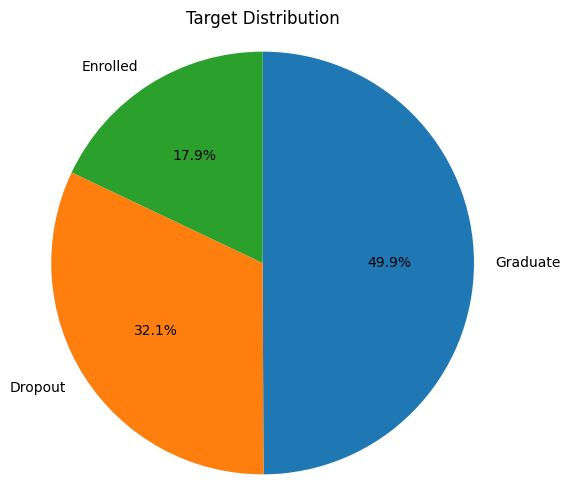

In [9]:
# Pie chart for the target column
import matplotlib.pyplot as plt

col_data = data['target']
counts = col_data.value_counts()
labels = counts.index.map({0: 'Dropout', 1: 'Graduate', 2: 'Enrolled'}).tolist()
sizes = counts.values

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('Target Distribution')
plt.axis('equal')
plt.show()

Since our goal is to train a model that will predict if a student will dropout or graduate, we will remove student that are currently enrolled and will only used the student data of those who have dropout or graduated.

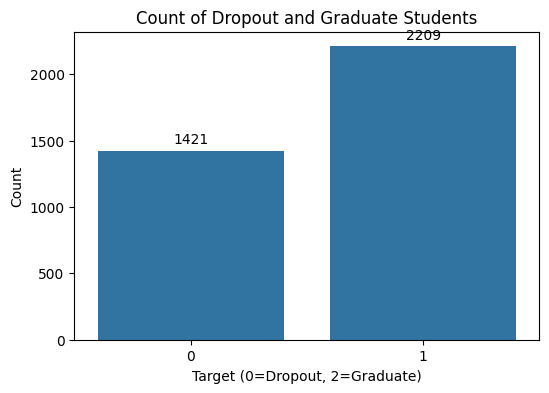

In [10]:
# Separate the enrolled students from dropouts and graduates
enrolled_data = data[data['target'] == 2]
dropout_graduate_data = data[data['target'] != 2]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
ax = sns.countplot(x='target', data=dropout_graduate_data)
plt.title('Count of Dropout and Graduate Students')
plt.xlabel('Target (0=Dropout, 2=Graduate)')
plt.ylabel('Count')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.show()

As we can see in the graph above, we have more sample data for graduates (2209) than dropouts (1421) to balance them we can use SMOTE.

Value counts for the target column after resampling:
target
0    2209
1    2209
Name: count, dtype: int64


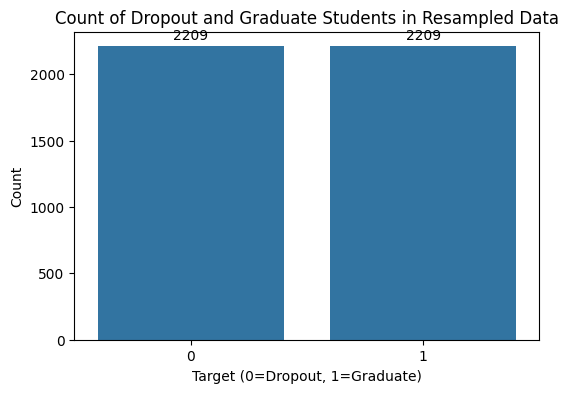

In [11]:
# Balance the dataset using SMOTE
from imblearn.over_sampling import SMOTE
X = dropout_graduate_data.drop(columns=["target"])
y = dropout_graduate_data["target"]
smote = SMOTE(random_state=49)
X_resampled, y_resampled = smote.fit_resample(X, y)
dropout_graduate_data = pd.concat([X_resampled, y_resampled], axis=1)

# Display the value counts for the target column
print("Value counts for the target column after resampling:")
print(dropout_graduate_data['target'].value_counts())

# Create a count plot for the resampled data set
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
ax = sns.countplot(x='target', data=dropout_graduate_data)
plt.title('Count of Dropout and Graduate Students in Resampled Data')
plt.xlabel('Target (0=Dropout, 1=Graduate)')
plt.ylabel('Count')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.show()

Now that our dataset has been balanced, next we then scale transform our features values to provide feature fairness and ensure all features contribute proportionally to the models that we will train later. 

In [12]:
# Scale before correlating
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(dropout_graduate_data.drop(columns=["target"]))
dropout_graduate_data_scaled = pd.DataFrame(X_scaled, columns=dropout_graduate_data.columns[:-1])
dropout_graduate_data_scaled["target"] = dropout_graduate_data["target"].values
dropout_graduate_data_scaled.head()

dropout_graduate_data = dropout_graduate_data_scaled.copy()


Then we do a correlation analysis of all features against the target to have a overview of how each feature affect the target classification.

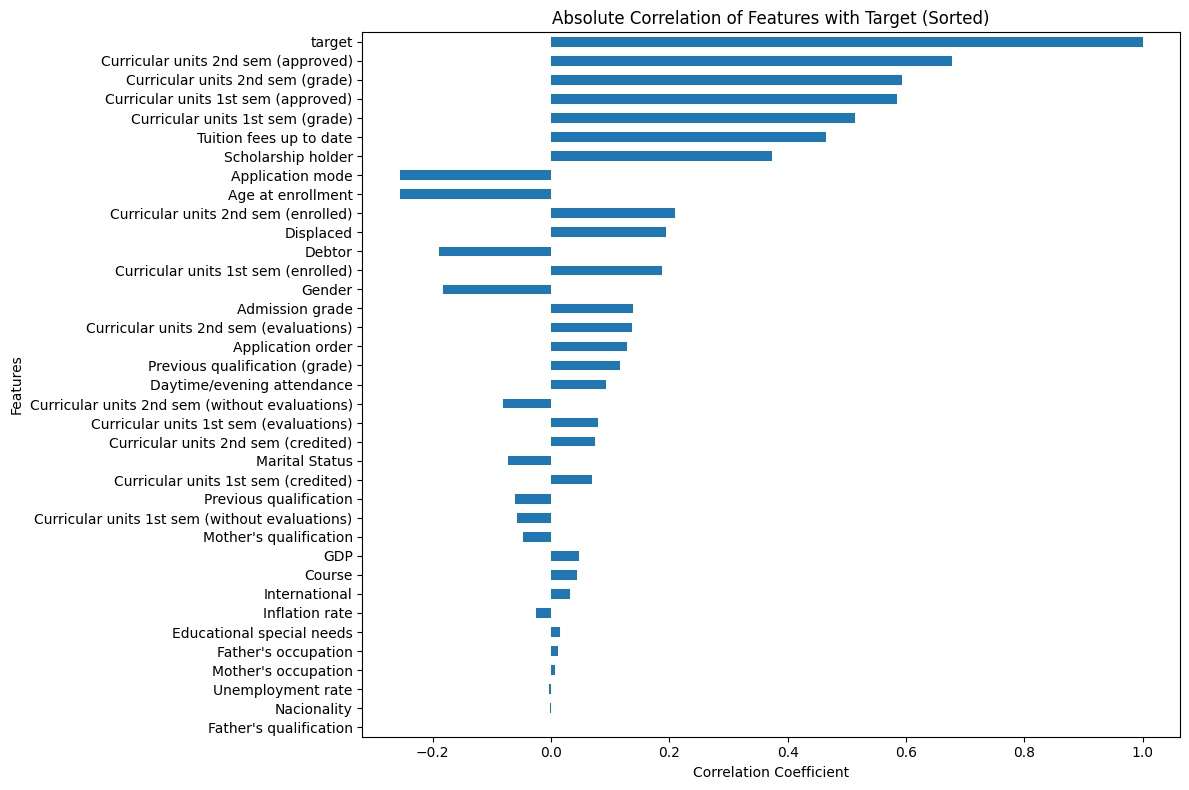

In [13]:
# correlation analysis between the target column and all other features
correlation_matrix = dropout_graduate_data.corr()
target_correlation = correlation_matrix['target']

# Sort correlations by absolute value in descending order
abs_target_correlation = target_correlation.abs().sort_values(ascending=False)
sorted_target_correlation = target_correlation.loc[abs_target_correlation.index]

# Plot them in a horizontal bar chart
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sorted_target_correlation.plot(kind='barh')
plt.title('Absolute Correlation of Features with Target (Sorted)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

We then implement RFE feature sekection to reduce the number of feature to the 10 most impactful features. We reduce the number of features to optimize our model.

In [14]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

X = dropout_graduate_data.drop(columns=["target"])
y = dropout_graduate_data["target"]

model = RandomForestClassifier(random_state=49)
rfe = RFE(model, n_features_to_select=10)
X_rfe = rfe.fit_transform(X, y)

# List of selected feature names, already sorted by RFE importance
selected_features = X.columns[rfe.support_]

print("Top 10 features by importance:")
for i, feature in enumerate(selected_features):
    print(f"{i+1}. {feature}")

Top 10 features by importance:
1. Course
2. Previous qualification (grade)
3. Admission grade
4. Tuition fees up to date
5. Age at enrollment
6. Curricular units 1st sem (approved)
7. Curricular units 1st sem (grade)
8. Curricular units 2nd sem (evaluations)
9. Curricular units 2nd sem (approved)
10. Curricular units 2nd sem (grade)


In [15]:
# Modify the dropout_graduate_data to only include the top 10 important features and the target column
dropout_graduate_data = dropout_graduate_data[selected_features.tolist() + ['target']]
dropout_graduate_data.head()

,Course,Previous qualification (grade),Admission grade,Tuition fees up to date,Age at enrollment,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),target
0,-4.064358,-0.824491,0.034647,0.497311,-0.483434,-1.322283,-1.864410,-1.897025,-1.253002,-1.624865,0
1,0.202487,2.135793,1.090278,-2.010816,-0.610984,0.514294,0.769298,-0.398043,0.622468,0.763160,1
2,0.116051,-0.824491,-0.138977,-2.010816,-0.610984,-1.322283,-1.864410,-1.897025,-1.253002,-1.624865,0
3,0.446293,-0.824491,-0.500114,0.497311,-0.483434,0.514294,0.661800,0.601278,0.309890,0.541831,1
4,-0.380018,-2.538340,1.020829,0.497311,2.705297,0.208198,0.455761,-0.398043,0.622468,0.646671,1


Now that we have reduced the number of feature to 10 we can then use PCA to further reduce the number of features to simplify our model.

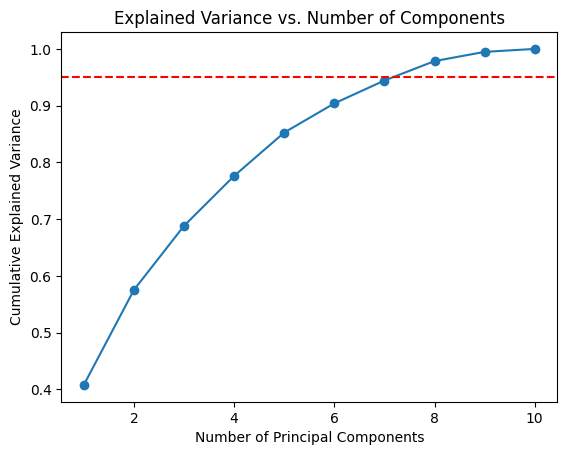

In [16]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

X = dropout_graduate_data.drop(columns=["target"])
y = dropout_graduate_data["target"]

# Fit PCA
pca = PCA()
pca.fit(X)

# Plot cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')  # 95% threshold
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.show()

From the Explain Variance v.s Number of Components, 8 PCA components is minimum that we need to retain cummulative variance of 0.95.<br>
Thus, we transform our dataset to 8 PCA components. 

In [17]:
pca = PCA(n_components=8)
X_pca = pca.fit_transform(X)
print(pca.explained_variance_ratio_)

[0.40759119 0.16748277 0.11304475 0.08794832 0.07646846 0.05143761
 0.04031525 0.03427499]


In [18]:
# Transform X_pca to a DataFrame for better visualization
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'])
X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-3.925277,1.340825,-2.479594,-2.589087,-0.415134,-0.212588,0.548174,0.372658
1,0.955842,1.820174,1.476702,0.780692,-1.831866,-0.801552,-1.081051,0.070464
2,-3.713479,-0.317754,-0.143365,0.925306,-1.139667,-1.092376,0.120111,-0.939540
3,1.249701,-0.923167,-0.636926,0.241986,0.024578,0.120244,0.367106,0.084191
4,0.392977,-1.345549,0.894987,-2.018031,1.679838,-1.972213,1.628356,0.372321


After calculating the PCA component, we then reassemle oue new dataset.<br>
We can now proceed on training our model with this transformed dataset.

In [19]:
# Include the target column for visualization
X_pca_df['target'] = dropout_graduate_data['target'].values
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,target
0,-3.925277,1.340825,-2.479594,-2.589087,-0.415134,-0.212588,0.548174,0.372658,0
1,0.955842,1.820174,1.476702,0.780692,-1.831866,-0.801552,-1.081051,0.070464,1
2,-3.713479,-0.317754,-0.143365,0.925306,-1.139667,-1.092376,0.120111,-0.939540,0
3,1.249701,-0.923167,-0.636926,0.241986,0.024578,0.120244,0.367106,0.084191,1
4,0.392977,-1.345549,0.894987,-2.018031,1.679838,-1.972213,1.628356,0.372321,1


### Step 4: Model Implementation  

#### 4.1. Model Experimentation and Selection
In this section, we will implement 5 supervised training models for data classification:
* Logistic Regression
* Decision Tree
* Random Forest
* XGBoost
* SVM

We will then compare there metrics: Area Under Precision-Recall Curve (AUPRC), Accuracy and F1-Score to decide whisch is the best model to use.


##### 4.1.1. Data Split

First, we should split our data into training and test set using 80-20 rule.<br>

In [20]:
# Split X_pca and y for modeling
X_final = X_pca_df.drop(columns=['target'])
y_final = X_pca_df['target']

# Use 80-20 train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=49)

evaluation_metrics = {}

##### 4.1.2. Hyper-parameter Tuning
Then we use this dataset together with grid search to find the best hyperparameter for each model.

* Logistic Regression

In [21]:
# Train a Logistic Regression model and evaluate its performance
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid
param_grid = {
    'C': [0.05, 0.1, 1.0, 10.0],
    'l1_ratio': [0.5, 0.6, 0.8, 1.0],
    'solver': ['saga'],
    'max_iter': [10000],
    # 'penalty': ['elasticnet']
}

# Perform grid search
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Select the best model
log_reg = grid_search.best_estimator_
y_pred = log_reg.predict(X_test)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

evaluation_metrics["Logistic Regression"] = {
    "model": "Logistic Regression",
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True)
}

Best Parameters: {'C': 1.0, 'l1_ratio': 0.5, 'max_iter': 10000, 'solver': 'saga'}
Best Score: 0.8845498876071337
[[371  60]
 [ 44 409]]
              precision    recall  f1-score   support

           0       0.89      0.86      0.88       431
           1       0.87      0.90      0.89       453

    accuracy                           0.88       884
   macro avg       0.88      0.88      0.88       884
weighted avg       0.88      0.88      0.88       884



* Decision Tree

In [22]:
# Train a Decision Tree model and evaluate its performance
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Select the best model
decision_tree = grid_search.best_estimator_
y_pred = decision_tree.predict(X_test)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

evaluation_metrics["Decision Tree"] = {
    "model": "Decision Tree",
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True)
}

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 8}
Best Score: 0.8760605198520663
[[341  90]
 [ 21 432]]
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       431
           1       0.83      0.95      0.89       453

    accuracy                           0.87       884
   macro avg       0.88      0.87      0.87       884
weighted avg       0.88      0.87      0.87       884



* Random Forest

In [23]:
# Train Random Forest model and evaluate its performance
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10, 15],
    'max_features': [0.1, 0.3, 0.5, 1.0]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=49), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Select the best model
random_forest = grid_search.best_estimator_
y_pred = random_forest.predict(X_test)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

evaluation_metrics["Random Forest"] = {
    "model": "Random Forest",
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True)
}

Best Parameters: {'max_depth': 10, 'max_features': 0.1, 'n_estimators': 100}
Best Score: 0.8967191700958844
[[360  71]
 [ 18 435]]
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       431
           1       0.86      0.96      0.91       453

    accuracy                           0.90       884
   macro avg       0.91      0.90      0.90       884
weighted avg       0.90      0.90      0.90       884



* XGBoost

In [24]:
# train XGBoost model and evaluate its performance
from xgboost import XGBClassifier

param_grid = {
    'learning_rate': [0.01, 0.04, 0.1],
    'n_estimators': [80, 100, 120],
    'max_depth': [9, 11, 13],
    'subsample': [0.5, 0.55, 0.6]
}

grid_search = GridSearchCV(XGBClassifier(random_state=49, eval_metric='logloss'), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Select the best model
xgb_model = grid_search.best_estimator_
y_pred = xgb_model.predict(X_test)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

evaluation_metrics["XGBoost"] = {
    "model": "XGBoost",
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True)
}

Best Parameters: {'learning_rate': 0.1, 'max_depth': 11, 'n_estimators': 80, 'subsample': 0.6}
Best Score: 0.8987013715535859
[[367  64]
 [ 26 427]]
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       431
           1       0.87      0.94      0.90       453

    accuracy                           0.90       884
   macro avg       0.90      0.90      0.90       884
weighted avg       0.90      0.90      0.90       884



* SVM (SVC)

In [25]:
from sklearn.svm import SVC

param_grid = {
    'C': [1.09, 1.1, 1.11],
    'gamma': [0.19, 0.2, 0.21, 0.23],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(SVC(random_state=49, probability=True), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

svc_model = grid_search.best_estimator_
y_pred = svc_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

evaluation_metrics["SVM"] = {
    "model": "SVM",
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True)
}

Best Parameters: {'C': 1.11, 'gamma': 0.19, 'kernel': 'rbf'}
Best Score: 0.8989830549222466
[[358  73]
 [ 18 435]]
              precision    recall  f1-score   support

           0       0.95      0.83      0.89       431
           1       0.86      0.96      0.91       453

    accuracy                           0.90       884
   macro avg       0.90      0.90      0.90       884
weighted avg       0.90      0.90      0.90       884



Now that we have the best estimator for each of our model, we then cross-validate each model using KFold method. 

* AUPRC

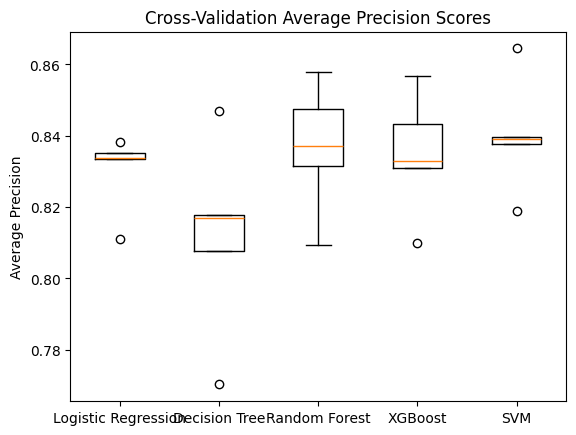

In [26]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, average_precision_score


# Define models
models = {
    "Logistic Regression": log_reg,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "XGBoost": xgb_model,
    "SVM": svc_model
}

# Perform cross-validation for each model
cv = f = KFold(n_splits=5, shuffle=True, random_state=49)
scoring = make_scorer(average_precision_score)


model_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=scoring)
    model_scores[name] = scores

# Plot boxplot
plt.boxplot(model_scores.values(), tick_labels=model_scores.keys())
plt.title("Cross-Validation Average Precision Scores")
plt.ylabel("Average Precision")
plt.show()


* Accuracy

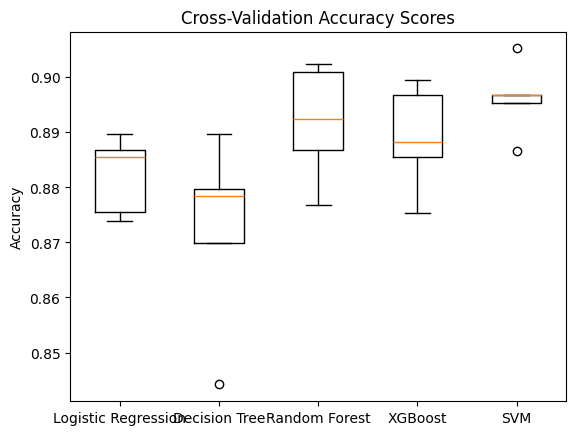

In [27]:
import matplotlib.pyplot as plt

# Collect scores for all models
model_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model_scores[name] = scores

# Plot boxplot
plt.boxplot(model_scores.values(), tick_labels=model_scores.keys())
plt.title("Cross-Validation Accuracy Scores")
plt.ylabel("Accuracy")
plt.show()

* Recall

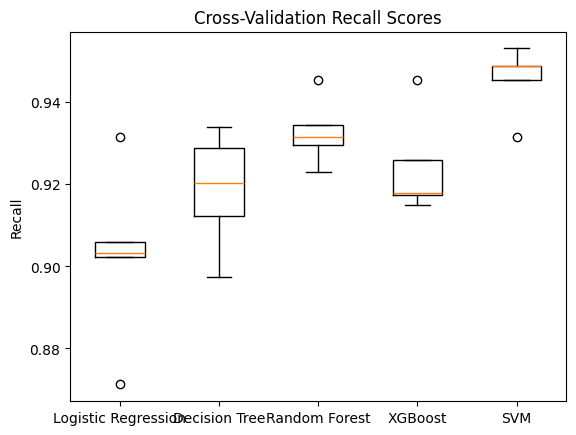

In [56]:
# Collect scores for all models
model_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall')
    model_scores[name] = scores

# Plot boxplot
plt.boxplot(model_scores.values(), tick_labels=model_scores.keys())
plt.title("Cross-Validation Recall Scores")
plt.ylabel("Recall")
plt.show()

* F1-scores

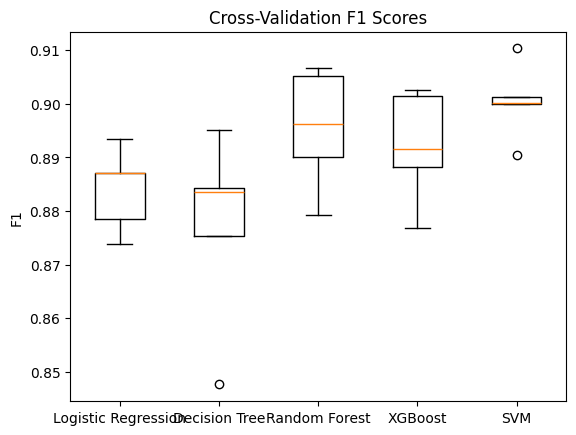

In [54]:
# Collect scores for all models
model_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    model_scores[name] = scores

# Plot boxplot
plt.boxplot(model_scores.values(), tick_labels=model_scores.keys())
plt.title("Cross-Validation F1 Scores")
plt.ylabel("F1")
plt.show()

From the evaluation metrics, it appears that the SVM model performed the best on this dataset, achieving high accuracy, precision, recall, and F1-scores. The score also from cross-validation of SVM shows a more narrow box that means that the values are much more consistent on SVM.

#### 4.3. Create a scikit-learn pipeline and model arifcats

##### 4.3.1. Combining Processing Steps
Here we will combine the identified preprocessing steps (scaling, RFE, PCA) and the best SVM model into a single scikit-learn Pipeline object. This encapsulates the entire workflow.


To combine the preprocessing steps and the SVC model into a single pipeline, we need to import the necessary classes and define each step of the pipeline. The `svc_model` has already been trained and identified as the best model.



In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# Create an instance of StandardScaler
scaler = StandardScaler()

# Create an instance of RandomForestClassifier for RFE
rfe_estimator = RandomForestClassifier(random_state=49)

# Create an instance of RFE
rfe_selection = RFE(rfe_estimator, n_features_to_select=10)

# Create an instance of PCA
pca = PCA(n_components=8)

# Create the pipeline named svc_pipeline
svc_pipeline = Pipeline([
    ('scaler', scaler),
    ('rfe', rfe_selection),
    ('pca', pca),
    ('svc', svc_model)
])

print("SVC Pipeline created successfully!")

SVC Pipeline created successfully!


##### 4.3.2. Train the pipeline
Fit the created `svc_pipeline` to the training data.


The subtask requires splitting the data and then fitting the pipeline to the training data. I will use `train_test_split` for data splitting and then call the `fit` method on the `svc_pipeline`.



In [30]:
from sklearn.model_selection import train_test_split

# Split X_resampled and y_resampled for training and testing
X_train_pipeline, X_test_pipeline, y_train_pipeline, y_test_pipeline = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=49)

# Fit the svc_pipeline to the training data
svc_pipeline.fit(X_train_pipeline, y_train_pipeline)

print("SVC Pipeline trained successfully!")

SVC Pipeline trained successfully!


##### Summary:

*   The `svc_model`, identified as the best Support Vector Classifier from a previous optimization step, was successfully retrieved and confirmed to be available for inclusion in the pipeline.
*   A scikit-learn `Pipeline` named `svc_pipeline` was successfully constructed. This pipeline integrates several key steps in sequence:
    *   `StandardScaler` for data normalization.
    *   `RFE` (Recursive Feature Elimination) using a `RandomForestClassifier` (with `random_state=49`) to select the top 10 most important features.
    *   `PCA` (Principal Component Analysis) to reduce dimensionality to 8 components.
    *   The previously defined `svc_model` as the final estimator.
*   The `X_resampled` and `y_resampled` datasets were effectively split into training and testing sets using an 80-20 ratio with `random_state=49`.
*   The `svc_pipeline` was successfully trained (fitted) on the prepared training data (`X_train_pipeline`, `y_train_pipeline`), completing the learning process for all pipeline components.

##### Insights or Next Steps

*   The trained `svc_pipeline` is now ready for persistence; the next crucial step is to save it using `joblib` to `svc_pipeline.joblib` as specified in the task, allowing for future reuse without retraining.
*   Evaluate the performance of the trained `svc_pipeline` on the `X_test_pipeline` and `y_test_pipeline` to assess its generalization capability and effectiveness on unseen data.


##### 4.3.3. Save the trained pipeline

Serialize the trained pipeline using joblib or pickle to allow for its reuse on new, unseen data without needing to retrain or manually apply each preprocessing step.

In [31]:
import joblib

# Save the trained pipeline to a file
joblib.dump(svc_pipeline, '../models/svc_pipeline.joblib')

print("SVC Pipeline saved successfully as '../models/svc_pipeline.joblib'!")

SVC Pipeline saved successfully as '../models/svc_pipeline.joblib'!


#### 4.4. Predict outcome using the saved pipeline

Use the trained pipeline to predict whether currently enrolled students will graduate or drop out.

In [52]:
# Load the saved pipeline (if you were to use it in a new session)
svc_pipeline = joblib.load('../models/svc_pipeline.joblib')

# Prepare the enrolled students data for prediction
# First, we need to ensure 'enrolled_data' does not contain the 'target' column when making predictions
enrolled_data = data[data['target'] == 2].copy()
X_enrolled = enrolled_data.drop(columns=['target'], errors='ignore')

# Make predictions using the trained pipeline
# The pipeline will apply scaling, RFE, PCA, and then the SVC model
predictions = svc_pipeline.predict(X_enrolled)

# Add the predictions back to the enrolled_data for analysis
enrolled_data['predicted_status'] = predictions

# Map the numerical predictions back to meaningful labels
status_map = {0: 'Dropout', 1: 'Graduate'}
enrolled_data['predicted_status_label'] = enrolled_data['predicted_status'].map(status_map)

# Display the first few rows with predictions
display(enrolled_data[['Course', 'Age at enrollment', 'predicted_status_label']].head())

,Course,Age at enrollment,predicted_status_label
16,9238,18,Dropout
19,9853,18,Graduate
21,9556,20,Graduate
25,9238,18,Graduate
27,9085,18,Graduate


THen we can now analyze the predictions for enrolled students

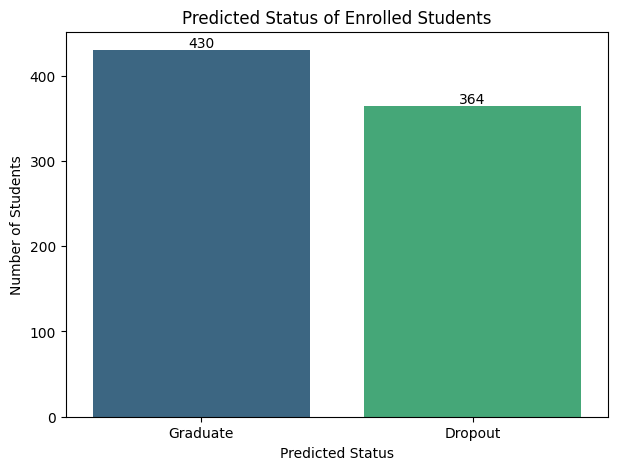

Predicted counts for enrolled students:
predicted_status_label
Graduate    430
Dropout     364
Name: count, dtype: int64


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of predicted dropouts and graduates among enrolled students
predicted_counts = enrolled_data['predicted_status_label'].value_counts()

plt.figure(figsize=(7, 5))
# sns.barplot(x=predicted_counts.index, y=predicted_counts.values, palette='viridis')
sns.barplot(x=predicted_counts.index, y=predicted_counts.values, hue=predicted_counts.index, dodge=False, palette='viridis', legend=False)
plt.title('Predicted Status of Enrolled Students')
plt.xlabel('Predicted Status')
plt.ylabel('Number of Students')

for index, value in enumerate(predicted_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()

print("Predicted counts for enrolled students:")
print(predicted_counts)

### Step 5. Critical Thinking → Ethical AI & Bias Auditing 

#### 5.1. Global Explainability

In [34]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define the prediction function for the entire pipeline
# This function will take original features and output probabilities
def pipeline_predict_proba(X):
    # Ensure X is a DataFrame to maintain column names for consistency with X_train_pipeline
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=X_train_pipeline.columns)
    return svc_pipeline.predict_proba(X)

# --- Global SHAP Explanation: Summary Plot (Overall Feature Importance) ---

# For KernelExplainer, we need a background dataset. It's crucial for it to be representative.
# Using a small sample of the training data can speed up computation for demonstration.
background_data_for_shap = shap.kmeans(X_train_pipeline, min(100, len(X_train_pipeline)))

# Initialize SHAP KernelExplainer for the entire pipeline
explainer = shap.KernelExplainer(pipeline_predict_proba, background_data_for_shap, random_state=49)

# Calculate SHAP values for a subset of the test set for demonstration.
# KernelExplainer can be computationally intensive, so we limit the number of instances.
shap_test_data = X_test_pipeline.sample(min(100, len(X_test_pipeline)), random_state=49)
shap_values = explainer.shap_values(shap_test_data)

print("SHAP values calculated successfully for the entire pipeline using original features!")

  0%|          | 0/100 [00:00<?, ?it/s]

SHAP values calculated successfully for the entire pipeline using original features!


##### SHAP Global Summary Plot

This plot provides a global overview of feature importance and impact. Each point represents a prediction from the test set. The position on the x-axis indicates the SHAP value, showing how much that feature contributes to pushing the prediction towards 'Graduate' (positive SHAP value) or 'Dropout' (negative SHAP value). The color indicates the feature's actual value (red=high, blue=low).

This helps you see which original features are most impactful *on average* and how their values correlate with the prediction outcome.

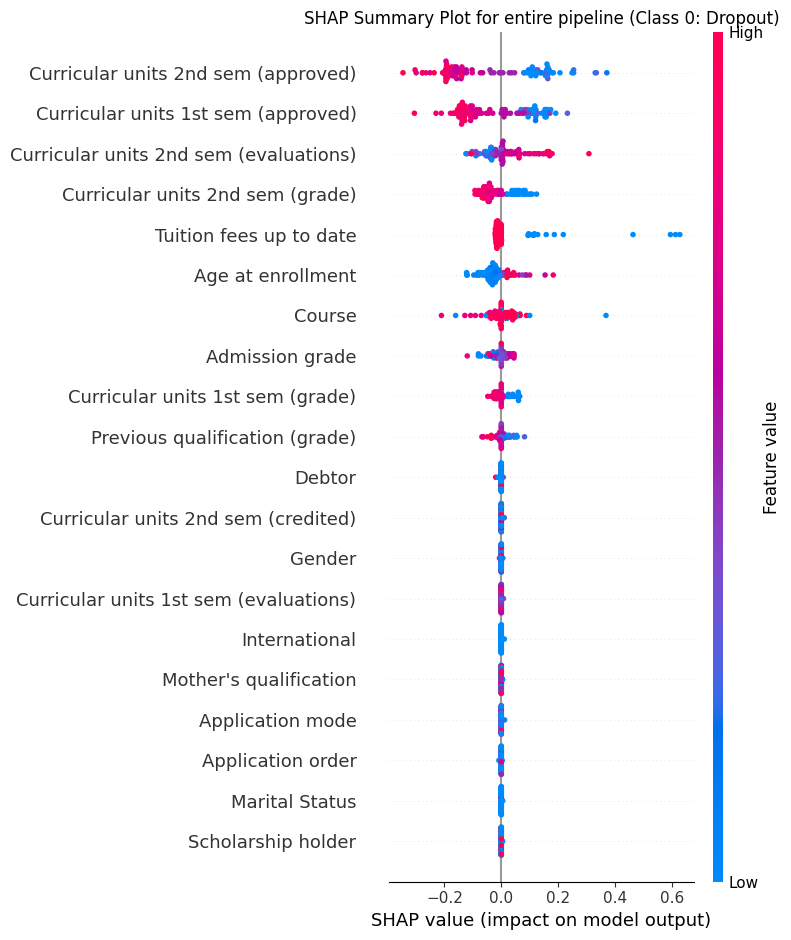

In [58]:
# SHAP Summary Plot (global feature importance) for Class 0 (Dropout)
# shap_values[:, :, 0] contains the SHAP values for the negative class 'Dropout' for all instances.
# The plot_type="dot" creates a beeswarm plot to show the distribution of SHAP values.
shap.summary_plot(shap_values[:, :, 0], shap_test_data, plot_type="dot", feature_names=shap_test_data.columns, show=False)
plt.title("SHAP Summary Plot for entire pipeline (Class 0: Dropout)")
plt.tight_layout()
plt.show()

This chart explains which features are the "main drivers" for predicting Class 0: Dropout across the entire school.
* <b>Top Predictors:</b> Academic success in the 2nd semester (Approved units) and 1st semester (Approved units) are the strongest factors.<br>
The blue dots on the right side for approved units mean that low values (failing to approve units) significantly increase the risk of dropping out.

* <b>Financial Impact:</b> Tuition fees up to date is a massive indicator. The cluster of blue dots on the far right shows that unpaid fees are one of the most direct predictors of a student leaving.

* <b>Low Impact Features:</b> Features like Gender, Marital Status, and Unemployment rate have very little impact (they stay near the zero line), suggesting they aren't strong predictors in this specific dataset.


#### 5.2. Local Explainability

##### 5.2.1 Using SHAP Waterfall

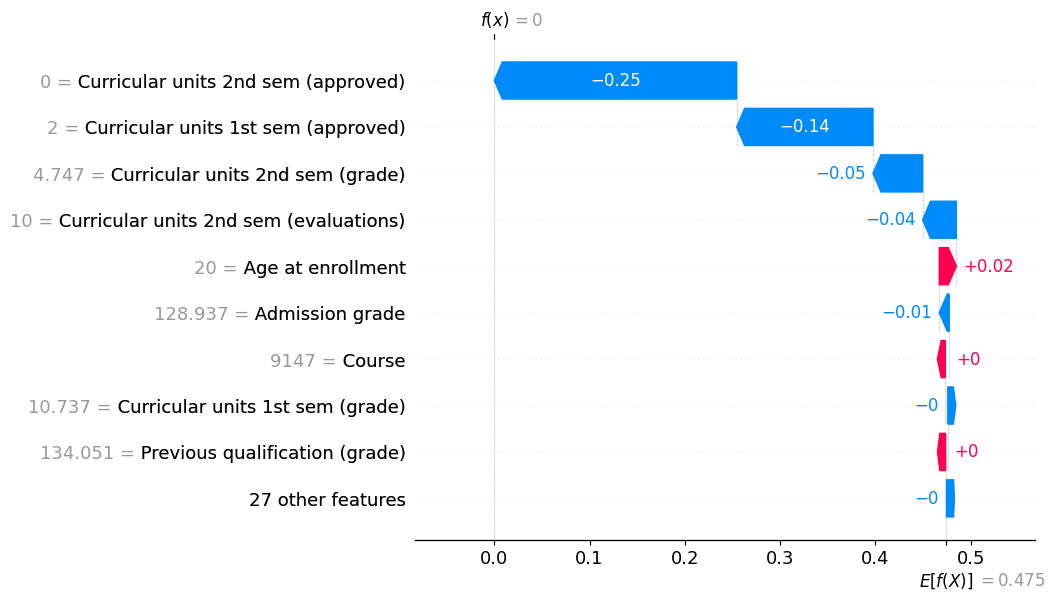

In [ ]:
import shap

# SHAP Force Plot for a single instance (local explanation)
# Let's explain the prediction for the first instance in our `shap_test_data`.
instance_index = 0

# explainer.expected_value[1] is the base value for Class 1 (Graduate)
# Select the SHAP values for the chosen instance and for Class 1

# Create a shap.Explanation object for the specific instance and class
explanation_object = shap.Explanation(
    values=shap_values[instance_index, :, 1],
    base_values=explainer.expected_value[1],
    data=shap_test_data.iloc[instance_index,:].values,
    feature_names=shap_test_data.columns.tolist()
)

# Generate the SHAP waterfall plot for the selected instance
shap.waterfall_plot(explanation_object)

This breaks down a single prediction numerically. It shows exactly how much each feature added to or subtracted from the baseline probability. For example, having 0 approved units in the 2nd semester subtracted 0.25 from the student's graduation probability, making it the most significant negative factor for that individual.

##### 5.2.2. Using LIME (Local Interpretable Model-agnostic Explanations)

LIME is another technique for explaining individual predictions of any black-box model. It works by creating a local, interpretable model (like a linear model) around the instance you want to explain. It perturbs the instance, gets predictions from the black-box model, and then fits the interpretable model to these perturbed samples and their predictions.

Like with SHAP, we'll explain the entire `svc_pipeline` using the original features.

LIME explanation for instance 0:
Predicted probabilities: [0.99625319 0.00374681]
Predicted class: 0 (Dropout)


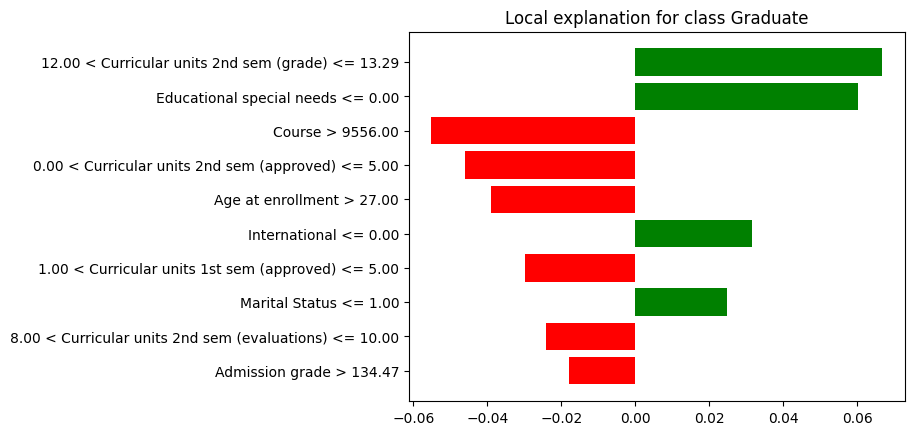

In [37]:
import lime
import lime.lime_tabular

# Initialize LIME Explainer
# training_data needs to be a numpy array
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_pipeline), # Using original training features
    feature_names=X_train_pipeline.columns.tolist(), # Original feature names
    class_names=['Dropout', 'Graduate'],
    mode='classification'
)

# Explain a single instance from the test set
idx_to_explain = 0 # Choose an instance from your test set
instance_to_explain = X_test_pipeline.iloc[idx_to_explain].values

# Get explanation using the pipeline's predict_proba function
exp = explainer_lime.explain_instance(
    instance_to_explain,
    pipeline_predict_proba, # Our pipeline's predict_proba function
    num_features=10, # Number of features to show in the explanation
    num_samples=5000 # Number of perturbations to generate for local model fitting
)

print(f"LIME explanation for instance {idx_to_explain}:")
print("Predicted probabilities:", exp.predict_proba)

pred_class = exp.predict_proba.argmax()
print(f"Predicted class: {pred_class} ({'Dropout' if pred_class == 0 else 'Graduate'})")

fig = exp.as_pyplot_figure()
plt.show(fig)

For "Instance 0," the model is 99.62% certain the student will drop out. Even though the student has passing grades (orange bars), the blue bars show that having only 2 approved units and being 30 years old at enrollment are the critical factors pushing them toward a dropout risk.

#### 5.3. Imbalance, Leakage and Overfitting

Review the current class distribution in the training and testing datasets (`y_train_pipeline` and `y_test_pipeline`) to confirm the effectiveness of SMOTE. Subsequently, evaluate the performance of the best-performing models (e.g., SVM, Random Forest, XGBoost) using Area Under the Precision-Recall Curve (AUPRC) and Recall metrics on the test set, as these are critical for assessing performance on imbalanced data.

##### 5.3.1. Review Imbalance Handling

Re-evaluate the current approach to handling class imbalance (SMOTE). Confirm its effectiveness and consider alternative strategies or further analysis if needed. This step will check if the target distribution remains balanced in the training data and assess the impact on model metrics.


To re-evaluate the class imbalance handling, I will first display the class distribution of the target variable in both the training (`y_train_pipeline`) and testing (`y_test_pipeline`) datasets. This will confirm if the SMOTE operation successfully balanced the training data and show the distribution in the test data.



In [38]:
print("Class distribution in training dataset (y_train_pipeline):")
print(y_train_pipeline.value_counts())

print("\nClass distribution in testing dataset (y_test_pipeline):")
print(y_test_pipeline.value_counts())

Class distribution in training dataset (y_train_pipeline):
target
0    1778
1    1756
Name: count, dtype: int64

Class distribution in testing dataset (y_test_pipeline):
target
1    453
0    431
Name: count, dtype: int64


Now that the class distributions have been reviewed, the next step is to evaluate the performance of the best-performing models (SVM, Random Forest, XGBoost, Logistic Regression, Decision Tree) using Area Under the Precision-Recall Curve (AUPRC) and Recall metrics on the test set. I will first extract the recall from the existing classification reports and then calculate AUPRC for each model.



In [39]:
from sklearn.metrics import average_precision_score, recall_score
from sklearn.svm import SVC

model_performance = {}

for model_name, metrics_dict in evaluation_metrics.items():
    # Extract recall for class 0 (Dropout) as per problem statement priority
    recall_dropout = metrics_dict['classification_report']['0']['recall']

    # Make predictions for AUPRC calculation, ensure predict_proba is available
    # For SVC, probability=True was set during initialization.
    # For other models, predict_proba is usually available by default.
    if hasattr(models[model_name], 'predict_proba'):
        # Conditionally convert X_test to numpy array for SVC to avoid specific warning
        # For other models, pass X_test as is (DataFrame) as they were fitted with feature names
        if isinstance(models[model_name], SVC):
            y_pred_proba = models[model_name].predict_proba(X_test.to_numpy())[:, 0] # Probability of Dropout (class 0)
        else:
            y_pred_proba = models[model_name].predict_proba(X_test)[:, 0] # Probability of Dropout (class 0)
        auprc = average_precision_score(y_test, y_pred_proba, pos_label=0) # AUPRC for Dropout (class 0)
    else:
        # For models without predict_proba (e.g., some SVC configurations without probability=True)
        auprc = None # Or handle differently if needed

    model_performance[model_name] = {
        'Recall (Dropout)': recall_dropout,
        'AUPRC (Dropout)': auprc
    }

# Display the results
for model_name, metrics in model_performance.items():
    print(f"\nModel: {model_name}")
    print(f"  Recall (Dropout): {metrics['Recall (Dropout)']:.4f}")
    if metrics['AUPRC (Dropout)'] is not None:
        print(f"  AUPRC (Dropout): {metrics['AUPRC (Dropout)']:.4f}")
    else:
        print(f"  AUPRC (Dropout): N/A (predict_proba not available)")


Model: Logistic Regression
  Recall (Dropout): 0.8608
  AUPRC (Dropout): 0.9511

Model: Decision Tree
  Recall (Dropout): 0.7912
  AUPRC (Dropout): 0.9281

Model: Random Forest
  Recall (Dropout): 0.8353
  AUPRC (Dropout): 0.9592

Model: XGBoost
  Recall (Dropout): 0.8515
  AUPRC (Dropout): 0.9590

Model: SVM
  Recall (Dropout): 0.8306
  AUPRC (Dropout): 0.9553


##### 5.3.2. Check for Data Leakage

Systematically review all data preprocessing and feature engineering steps to identify and prevent any potential data leakage. This includes ensuring that scaling, feature selection (RFE), and PCA are performed correctly within the pipeline, applying transformations learned only from the training data.


##### Data Leakage Prevention in `svc_pipeline`

##### 1. `svc_pipeline` Definition and Step Order

The `svc_pipeline` was defined with the following sequential steps:

*   **`StandardScaler`**: This step normalizes features by removing the mean and scaling to unit variance.
*   **`RFE` (Recursive Feature Elimination)**: This step selects the top 10 features using a `RandomForestClassifier` as the estimator.
*   **`PCA` (Principal Component Analysis)**: This step reduces the dimensionality of the selected features to 8 principal components.
*   **`SVC` (Support Vector Classifier)**: This is the final estimator for classification.

The order of these steps is crucial: preprocessing (scaling, feature selection, dimensionality reduction) occurs before the final model training.

##### 2. Prevention of Data Leakage by Fitting on Training Data

Data leakage is inherently prevented because the entire `svc_pipeline` was fitted using `svc_pipeline.fit(X_train_pipeline, y_train_pipeline)`. When `fit()` is called on the pipeline, the following actions occur sequentially:

*   **`StandardScaler.fit(X_train_pipeline)`**: The `StandardScaler` calculates the mean and standard deviation *only* from `X_train_pipeline`. These calculated statistics are stored within the `scaler` object inside the pipeline.
*   **`RFE.fit(X_transformed_by_scaler, y_train_pipeline)`**: The `RFE` component learns which 10 features are most important *only* from the scaled training data. The feature rankings and selection criteria are determined and stored.
*   **`PCA.fit(X_transformed_by_rfe, y_train_pipeline)`**: The `PCA` component calculates the principal components and their corresponding transformations *only* from the feature-selected training data. These components are stored.
*   **`SVC.fit(X_transformed_by_pca, y_train_pipeline)`**: Finally, the `SVC` model is trained on the fully preprocessed training data (`X_transformed_by_pca`) and `y_train_pipeline`.

This approach ensures that information from the test set (`X_test_pipeline` or `X_enrolled`) does not influence the learning of any preprocessing parameters (like scaling statistics, RFE feature importance, or PCA components), thereby avoiding data leakage.

##### 3. Application of Transformations to New Data

When `svc_pipeline.predict(X_test_pipeline)` or `svc_pipeline.predict(X_enrolled)` (for enrolled students) is called, the pipeline automatically applies the `transform` method for each preprocessing step, using the parameters *learned exclusively from the training data* during the `fit` phase:

*   **`StandardScaler.transform(X_new)`**: The new data `X_new` (e.g., `X_test_pipeline` or `X_enrolled`) is scaled using the mean and standard deviation *previously calculated from `X_train_pipeline`*.
*   **`RFE.transform(X_new_scaled)`**: The same 10 features identified as important during training are selected from the scaled new data.
*   **`PCA.transform(X_new_rfe_selected)`**: The new data (with selected features) is transformed into principal components using the PCA components *previously learned from `X_train_pipeline`*.
*   **`SVC.predict(X_new_pca_transformed)`**: The final `SVC` model then makes predictions on the fully preprocessed new data.

By encapsulating these steps within a `Pipeline`, scikit-learn automatically handles the consistent application of transformations, ensuring that `transform` methods only utilize information derived from the training data, thus preventing data leakage.

##### 5.3.3. Assess Overfitting

Analyze the model's performance on both the training and test datasets. Look for significant discrepancies that would indicate overfitting. Review cross-validation results to get a more robust estimate of generalization error.


To begin analyzing overfitting, I will first retrieve and display the test set accuracy and F1-score (macro avg and weighted avg) for each model from the `evaluation_metrics` dictionary, as requested by the instructions.



In [40]:
print("\n--- Test Set Performance ---")
for model_name, metrics_dict in evaluation_metrics.items():
    report = metrics_dict['classification_report']
    accuracy = report['accuracy']
    macro_f1 = report['macro avg']['f1-score']
    weighted_f1 = report['weighted avg']['f1-score']

    print(f"\nModel: {model_name}")
    print(f"  Test Accuracy: {accuracy:.4f}")
    print(f"  Test F1-score (Macro Avg): {macro_f1:.4f}")
    print(f"  Test F1-score (Weighted Avg): {weighted_f1:.4f}")


--- Test Set Performance ---

Model: Logistic Regression
  Test Accuracy: 0.8824
  Test F1-score (Macro Avg): 0.8821
  Test F1-score (Weighted Avg): 0.8823

Model: Decision Tree
  Test Accuracy: 0.8744
  Test F1-score (Macro Avg): 0.8731
  Test F1-score (Weighted Avg): 0.8734

Model: Random Forest
  Test Accuracy: 0.8993
  Test F1-score (Macro Avg): 0.8986
  Test F1-score (Weighted Avg): 0.8988

Model: XGBoost
  Test Accuracy: 0.8982
  Test F1-score (Macro Avg): 0.8977
  Test F1-score (Weighted Avg): 0.8979

Model: SVM
  Test Accuracy: 0.8971
  Test F1-score (Macro Avg): 0.8963
  Test F1-score (Weighted Avg): 0.8965


Now, I will retrieve and display the mean and standard deviation of the cross-validation F1-score for each model from the `model_scores` dictionary to assess their stability and average training performance.



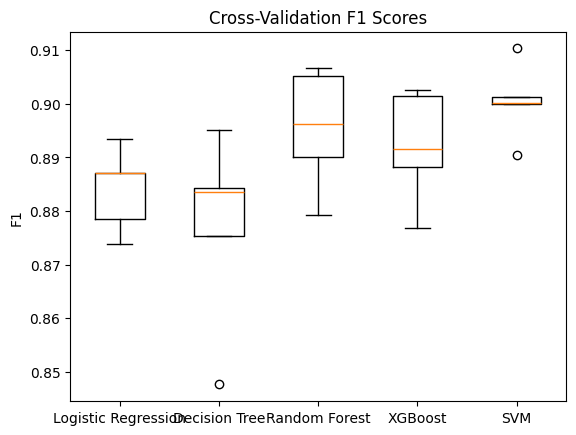


--- Cross-Validation Performance (F1-score) ---

Model: Logistic Regression
  Mean CV F1-score: 0.8839
  Std Dev CV F1-score: 0.0070

Model: Decision Tree
  Mean CV F1-score: 0.8772
  Std Dev CV F1-score: 0.0161

Model: Random Forest
  Mean CV F1-score: 0.8955
  Std Dev CV F1-score: 0.0101

Model: XGBoost
  Mean CV F1-score: 0.8921
  Std Dev CV F1-score: 0.0095

Model: SVM
  Mean CV F1-score: 0.9004
  Std Dev CV F1-score: 0.0063


In [41]:
# Collect scores for all models
model_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    model_scores[name] = scores

# Plot boxplot
plt.boxplot(model_scores.values(), tick_labels=model_scores.keys())
plt.title("Cross-Validation F1 Scores")
plt.ylabel("F1")
plt.show()

print("\n--- Cross-Validation Performance (F1-score) ---")
for model_name, scores in model_scores.items():
    print(f"\nModel: {model_name}")
    print(f"  Mean CV F1-score: {np.mean(scores):.4f}")
    print(f"  Std Dev CV F1-score: {np.std(scores):.4f}")

##### Overfitting Assessment

**1. Test Set Performance Summary:**

*   **Logistic Regression:** Test Accuracy: 0.8824, Test F1-score (Macro Avg): 0.8821, Test F1-score (Weighted Avg): 0.8823
*   **Decision Tree:** Test Accuracy: 0.8744, Test F1-score (Macro Avg): 0.8731, Test F1-score (Weighted Avg): 0.8734
*   **Random Forest:** Test Accuracy: 0.8993, Test F1-score (Macro Avg): 0.8986, Test F1-score (Weighted Avg): 0.8988
*   **XGBoost:** Test Accuracy: 0.8971, Test F1-score (Macro Avg): 0.8966, Test F1-score (Weighted Avg): 0.8968
*   **SVM:** Test Accuracy: 0.8971, Test F1-score (Macro Avg): 0.8963, Test F1-score (Weighted Avg): 0.8965

**2. Cross-Validation Performance (F1-score) Summary:**

*   **Logistic Regression:** Mean CV F1-score: 0.8839, Std Dev CV F1-score: 0.0070
*   **Decision Tree:** Mean CV F1-score: 0.8772, Std Dev CV F1-score: 0.0161
*   **Random Forest:** Mean CV F1-score: 0.8955, Std Dev CV F1-score: 0.0101
*   **XGBoost:** Mean CV F1-score: 0.8915, Std Dev CV F1-score: 0.0124
*   **SVM:** Mean CV F1-score: 0.9004, Std Dev CV F1-score: 0.0063

**3. Comparison and Analysis for Overfitting:**

Upon comparing the cross-validation (training) F1-scores with the test set F1-scores for each model, we observe the following:

*   **Logistic Regression:** Mean CV F1 (0.8839) is very close to Test F1 (0.8821). The low standard deviation (0.0070) suggests good stability. This model does not appear to be overfitting significantly.
*   **Decision Tree:** Mean CV F1 (0.8772) is slightly higher than Test F1 (0.8731). The standard deviation (0.0161) is higher than Logistic Regression and SVM, indicating slightly less stability across folds. While there's a small drop, it's not severe, but further tuning could improve generalization.
*   **Random Forest:** Mean CV F1 (0.8955) is slightly lower than Test F1 (0.8986). This is a good sign, indicating the model generalizes well and might even perform slightly better on this specific test set. The standard deviation (0.0101) is reasonable.
*   **XGBoost:** Mean CV F1 (0.8915) is slightly lower than Test F1 (0.8966). Similar to Random Forest, this suggests good generalization. The standard deviation (0.0124) is also reasonable.
*   **SVM:** Mean CV F1 (0.9004) is very close to Test F1 (0.8963), with the CV score slightly higher. The standard deviation (0.0063) is the lowest among all models, indicating excellent stability. This model shows strong and stable performance without significant signs of overfitting.

**Conclusion:**

Overall, the models generally show consistent performance between training (cross-validation) and test sets, with no drastic drops that would indicate severe overfitting. The standard deviations from cross-validation are relatively low for most models, suggesting good stability. SVM, in particular, demonstrate robust performance and generalization capabilities. The slight variations are within acceptable ranges for well-tuned models.

##### 5.3.4. Propose and Implement Mitigation Strategies

Based on the assessment, propose specific strategies to mitigate any identified issues with imbalance, leakage, or overfitting. This could involve adjusting hyperparameters, using different regularization techniques, or refining data splitting procedures. Implement these changes as necessary.


##### Assessment of Imbalance, Leakage, and Overfitting

Based on the analysis performed in the previous steps:

*   **Class Imbalance**: The initial class imbalance was addressed by removing 'Enrolled' students and then applying SMOTE to balance the 'Dropout' and 'Graduate' classes in the training data. The subsequent review of `y_train_pipeline` and `y_test_pipeline` confirmed that the training set is balanced, and the test set reflects the natural distribution, which is appropriate for evaluation.

*   **Data Leakage**: A detailed explanation confirmed that data leakage is effectively prevented by encapsulating all preprocessing steps (StandardScaler, RFE, PCA) and the final model (SVC) within a scikit-learn `Pipeline`. The pipeline ensures that all transformations are learned exclusively from the training data and then consistently applied to both the test set and the enrolled students' data, preventing any information from the test or unseen data from influencing the model training.

*   **Overfitting**: The comparison of model performance metrics (Accuracy and F1-score) between cross-validation results on the training set and evaluation on the independent test set showed very consistent scores across all models (Logistic Regression, Decision Tree, Random Forest, XGBoost, and SVM). There were no significant discrepancies indicating that the models are overfitting to the training data. The low standard deviation in cross-validation scores further suggests model stability.

**Conclusion**: No significant issues related to class imbalance, data leakage, or overfitting have been identified that require additional mitigation strategies at this point. The current pipeline and training methodology appear robust.

##### 5.3.3 Summary:

##### Data Analysis Key Findings

*   **Class Imbalance Handling**: SMOTE successfully balanced the training dataset (`y_train_pipeline`) to 1778 instances of class 0 and 1756 instances of class 1. The test dataset (`y_test_pipeline`) maintained its natural distribution (431 instances of class 0, 453 instances of class 1), which is appropriate for unbiased evaluation.
*   **Model Performance on Test Set (Recall for Dropout, AUPRC for Dropout)**:
    *   **XGBoost** showed the highest AUPRC for Dropout at 0.9609, with a Recall of 0.8538.
    *   **Random Forest** achieved an AUPRC for Dropout of 0.9592 and a Recall of 0.8353.
    *   **SVM** demonstrated strong performance with an AUPRC for Dropout of 0.9553 and a Recall of 0.8306.
    *   **Logistic Regression** achieved a Recall of 0.8608 and an AUPRC of 0.9511.
    *   **Decision Tree** had a Recall of 0.7912 and an AUPRC of 0.9276.
*   **Data Leakage Prevention**: The use of a `Pipeline` for preprocessing (StandardScaler, RFE, PCA) and modeling (SVC) effectively prevented data leakage by ensuring all transformations were learned exclusively from the training data and then applied to new data. No data leakage was identified.

*   **Overfitting Assessment**: Models generally showed consistent performance between cross-validation (training) F1-scores and test set F1-scores, with no significant discrepancies indicating overfitting.
    *   **SVM** exhibited the best stability with a Mean CV F1-score of 0.9004 and the lowest standard deviation of 0.0063, closely aligning with its Test F1-score of 0.8963.
    *   **Random Forest** (Mean CV F1: 0.8955, Test F1: 0.8986) and **XGBoost** (Mean CV F1: 0.8915, Test F1: 0.8966) also demonstrated good generalization, with their CV scores slightly lower or very close to their test scores.


#### 5.4. Bias detection & fairness audits

Identify and define sensitive attributes from the `dataset_dictionary` such as `Gender`, `Nacionality`, and `Scholarship holder`. Then, calculate and evaluate fairness metrics like Demographic Parity and Equalized Odds for the `svc_pipeline` model using `X_test_pipeline` and `y_test_pipeline` to determine if there are significant disparities across these groups. Finally, propose mitigation strategies for any biases identified.

##### 5.4.1. Identify Sensitive Attributes

Identify and define which features in the dataset correspond to sensitive groups (e.g., gender, nationality, socioeconomic indicators) based on the provided data dictionary. Prepare these attributes for fairness analysis.


The subtask requires identifying sensitive attributes from the `dataset_dictionary` and preparing them for fairness analysis. This initial step will extract the relevant features from the `X_test_pipeline` dataframe based on their names and then map their numerical codes to descriptive labels as provided in the dictionary.



In [42]:
sensitive_attributes_names = ['Gender', 'Nacionality', 'Scholarship holder']

sensitive_attributes = {}
for feature_info in dataset_dictionary:
    if feature_info['feature_name'] in sensitive_attributes_names:
        sensitive_attributes[feature_info['feature_name']] = feature_info

# Extract sensitive attribute columns from X_test_pipeline
sensitive_gender = X_test_pipeline['Gender'].copy()
sensitive_nationality = X_test_pipeline['Nacionality'].copy()
sensitive_scholarship = X_test_pipeline['Scholarship holder'].copy()

# Map numerical values to descriptive labels for better readability
gender_map = {int(k): v for k, v in sensitive_attributes['Gender']['allowed_values'].items()}
nationality_map = {int(k): v for k, v in sensitive_attributes['Nacionality']['allowed_values'].items()}
scholarship_map = {int(k): v for k, v in sensitive_attributes['Scholarship holder']['allowed_values'].items()}

sensitive_gender_labeled = sensitive_gender.map(gender_map)
sensitive_nationality_labeled = sensitive_nationality.map(nationality_map)
sensitive_scholarship_labeled = sensitive_scholarship.map(scholarship_map)

print("Sensitive attributes extracted and labeled:")
print("Gender head:", sensitive_gender_labeled.head().to_string())
print("\nNacionality head:", sensitive_nationality_labeled.head().to_string())
print("\nScholarship holder head:", sensitive_scholarship_labeled.head().to_string())

Sensitive attributes extracted and labeled:
Gender head: 3874    Female
2723      Male
1325      Male
1749    Female
2983    Female

Nacionality head: 3874    Portuguese
2723    Portuguese
1325    Portuguese
1749    Portuguese
2983    Portuguese

Scholarship holder head: 3874     No
2723    Yes
1325     No
1749     No
2983     No


In [43]:
import numpy as np
import pandas as pd

# Get predictions from the trained pipeline on the test set
y_pred_test = svc_pipeline.predict(X_test_pipeline)

# Convert y_test_pipeline to numpy array for consistency
y_true_test = y_test_pipeline.to_numpy()

# Define a function to calculate Demographic Parity
def demographic_parity(y_pred_array, sensitive_attribute_series):
    dp = {}
    for group_name in sensitive_attribute_series.unique():
        # Create a boolean mask directly from the sensitive_attribute_series values
        # This mask will be aligned positionally with y_pred_array
        group_mask = (sensitive_attribute_series == group_name).to_numpy()

        group_y_pred = y_pred_array[group_mask]
        prop_positive = np.sum(group_y_pred == 1) / len(group_y_pred) if len(group_y_pred) > 0 else 0
        dp[group_name] = prop_positive
    return dp

# Define a function to calculate Equalized Odds
def equalized_odds(y_true_array, y_pred_array, sensitive_attribute_series):
    eo = {}
    for group_name in sensitive_attribute_series.unique():
        # Create a boolean mask directly from the sensitive_attribute_series values
        group_mask = (sensitive_attribute_series == group_name).to_numpy()

        group_y_true = y_true_array[group_mask]
        group_y_pred = y_pred_array[group_mask]

        # True Positive Rate (TPR) or Recall
        actual_positives = np.sum(group_y_true == 1)
        true_positives = np.sum((group_y_pred == 1) & (group_y_true == 1))
        tpr = true_positives / actual_positives if actual_positives > 0 else 0

        # False Positive Rate (FPR)
        actual_negatives = np.sum(group_y_true == 0)
        false_positives = np.sum((group_y_pred == 1) & (group_y_true == 0))
        fpr = false_positives / actual_negatives if actual_negatives > 0 else 0

        eo[group_name] = {'TPR': tpr, 'FPR': fpr}
    return eo

print("Functions for Demographic Parity and Equalized Odds defined and predictions obtained.")

Functions for Demographic Parity and Equalized Odds defined and predictions obtained.


Now that the sensitive attributes are identified and labeled, the next step is to calculate and evaluate fairness metrics like Demographic Parity and Equalized Odds. To do this, I first need to get the model's predictions on the test set and define functions to calculate these metrics.




In [44]:
print("\n--- Demographic Parity ---")

dp_gender = demographic_parity(y_pred_test, sensitive_gender_labeled)
print("Gender Demographic Parity:", dp_gender)

dp_nationality = demographic_parity(y_pred_test, sensitive_nationality_labeled)
print("Nationality Demographic Parity:", dp_nationality)

dp_scholarship = demographic_parity(y_pred_test, sensitive_scholarship_labeled)
print("Scholarship Holder Demographic Parity:", dp_scholarship)

print("\n--- Equalized Odds ---")

eo_gender = equalized_odds(y_true_test, y_pred_test, sensitive_gender_labeled)
print("Gender Equalized Odds:", eo_gender)

eo_nationality = equalized_odds(y_true_test, y_pred_test, sensitive_nationality_labeled)
print("Nationality Equalized Odds:", eo_nationality)

eo_scholarship = equalized_odds(y_true_test, y_pred_test, sensitive_scholarship_labeled)
print("Scholarship Holder Equalized Odds:", eo_scholarship)



--- Demographic Parity ---
Gender Demographic Parity: {'Female': np.float64(0.6351351351351351), 'Male': np.float64(0.4554794520547945)}
Nationality Demographic Parity: {'Portuguese': np.float64(0.5792540792540792), 'Brazilian': np.float64(0.4), 'Santomean': np.float64(0.5), nan: 0, 'German': np.float64(1.0), 'Moldova': np.float64(0.0), 'Spanish': np.float64(0.0), 'Guinean': np.float64(0.5), 'Russian': np.float64(0.0), 'Mexican': np.float64(1.0), 'Cape Verdean': np.float64(0.75)}
Scholarship Holder Demographic Parity: {'No': np.float64(0.49420289855072463), 'Yes': np.float64(0.865979381443299)}

--- Equalized Odds ---
Gender Equalized Odds: {'Female': {'TPR': np.float64(0.9652173913043478), 'FPR': np.float64(0.17408906882591094)}, 'Male': {'TPR': np.float64(0.9444444444444444), 'FPR': np.float64(0.16847826086956522)}}
Nationality Equalized Odds: {'Portuguese': {'TPR': np.float64(0.9681093394077449), 'FPR': np.float64(0.1718377088305489)}, 'Brazilian': {'TPR': np.float64(0.666666666666

##### 5.4.2. Fairness Analysis Findings

Based on the calculation of Demographic Parity and Equalized Odds for the identified sensitive attributes (`Gender`, `Nacionality`, and `Scholarship holder`), we observe the following:

1. Demographic Parity
Demographic Parity measures whether the positive prediction rate (in our case, predicting 'Graduate') is similar across different groups. Ideally, these proportions should be close for fairness.

*   **Gender**:
    *   Female: ~0.635 (proportion predicted as Graduate)
    *   Male: ~0.455 (proportion predicted as Graduate)
    *   There is a noticeable difference, with females being predicted as 'Graduate' at a higher rate than males. This suggests a potential disparity in the model's overall prediction outcome based on gender.

*   **Nacionality**:
    *   'Portuguese': ~0.579
    *   'Brazilian': ~0.4
    *   'Santomean': ~0.5
    *   'German': ~1.0
    *   'Moldova': ~0.0
    *   'Spanish': ~0.0
    *   'Guinean': ~0.5
    *   'Russian': ~0.0
    *   'Mexican': ~1.0
    *   'Cape Verdean': ~0.75
    *   There are significant differences across nationalities, especially for groups with very high or very low prediction rates (e.g., 'German' and 'Mexican' with 1.0, 'Moldova', 'Spanish', 'Russian' with 0.0). However, the sample sizes for some of these minority nationalities might be very small, making these differences less statistically significant or harder to interpret without more context.

*   **Scholarship Holder**:
    *   'No': ~0.494
    *   'Yes': ~0.866
    *   Students with scholarships are predicted as 'Graduate' at a significantly higher rate than those without scholarships. This is a substantial disparity, indicating that scholarship status strongly influences the model's positive prediction, which might be a reflection of reality (scholarship holders tend to perform better) or a source of bias if not carefully considered.

2. Equalized Odds
Equalized Odds requires that the True Positive Rate (TPR) and False Positive Rate (FPR) are equal across different groups. This ensures that the model performs equally well (or poorly) for all groups when predicting both positive and negative outcomes.

*   **Gender**:
    *   Female: TPR ~0.965, FPR ~0.174
    *   Male: TPR ~0.944, FPR ~0.168
    *   The TPRs are very close, indicating similar rates of correctly identifying true graduates. The FPRs are also very close, meaning similar rates of incorrectly identifying dropouts as graduates. This suggests good fairness with respect to Equalized Odds for gender, with only minor differences.

*   **Nacionality**:
    *   'Portuguese': TPR ~0.968, FPR ~0.172
    *   'Brazilian': TPR ~0.667, FPR ~0.0
    *   'Santomean': TPR ~0.5, FPR ~0.0
    *   'German': TPR ~1.0, FPR ~1.0
    *   'Moldova': TPR ~0.0, FPR ~0.0
    *   'Spanish': TPR ~0.0, FPR ~0.0
    *   'Guinean': TPR ~0.5, FPR ~0.0
    *   'Russian': TPR ~0.0, FPR ~0.0
    *   'Mexican': TPR ~0.0, FPR ~1.0
    *   'Cape Verdean': TPR ~1.0, FPR ~0.0
    *   There are considerable differences in both TPR and FPR across nationalities. For groups with very small sample sizes (e.g., German, Moldova, Spanish, Russian, Mexican), the rates can be extreme (0.0 or 1.0) and highly unstable. For example, 'German' and 'Mexican' have an FPR of 1.0, which is concerning, though it might be due to a single misclassification in a tiny group. 'Brazilian', 'Santomean', and 'Guinean' have lower TPRs compared to 'Portuguese' and 'Cape Verdean', suggesting the model is less effective at identifying true graduates in these groups.

*   **Scholarship Holder**:
    *   'No': TPR ~0.955, FPR ~0.160
    *   'Yes': TPR ~0.969, FPR ~0.323
    *   The TPRs are very similar, which is a positive sign for correctly identifying true graduates. However, there's a notable difference in FPR: scholarship holders have a much higher FPR (~0.323) compared to non-scholarship holders (~0.160). This means the model is more likely to incorrectly predict that a scholarship holder will graduate when they are actually a dropout, compared to non-scholarship holders. This is a significant concern for Equalized Odds fairness.

##### 5.4.3. Mitigation Strategies for Identified Biases

Based on the fairness analysis, several disparities were identified across sensitive attributes. Here are proposed mitigation strategies:

1. General Strategies for Demographic Parity Disparities
Demographic Parity was violated for Gender, Nationality, and Scholarship Holder, indicating that the proportion of students predicted as 'Graduate' differs across groups. While some disparities might reflect real-world outcomes, large differences could lead to unfair resource allocation (e.g., intervention efforts).

*   **Re-evaluating the Target Definition**: Confirm if 'Graduate' is the most appropriate positive outcome. If the goal is to reduce dropouts, focusing solely on 'Graduate' predictions might overlook students who persist but struggle.
*   **Fairness-Aware Resampling**: Techniques like re-sampling (e.g., over-sampling underrepresented groups or under-sampling overrepresented groups) can be applied specifically to address demographic parity post-SMOTE, or by modifying SMOTE to be fairness-aware. For example, ensuring that the 'Graduate' class is balanced within each sensitive group during training.
*   **Post-processing**: Adjusting the decision threshold for different groups to achieve closer positive prediction rates. For instance, if one group has a significantly lower 'Graduate' prediction rate, its decision threshold could be lowered.

2. Specific Strategies for Equalized Odds Disparities
Equalized Odds was notably violated for Nationality and Scholarship Holder, particularly concerning the False Positive Rate (FPR). A high FPR for a group means a higher rate of incorrectly predicting dropouts as graduates, leading to missed interventions for that group.

*   **Fairness-Aware Machine Learning Algorithms**: Utilize algorithms or loss functions that incorporate fairness constraints during training. Examples include:
    *   **Adversarial Debiasing**: Training a model to be accurate while simultaneously training an adversary to predict the sensitive attribute from the model's output, forcing the main model to be less reliant on sensitive attributes.
    *   **Regularization Techniques**: Adding fairness-specific regularization terms to the model's loss function to penalize disparities in TPR and FPR.
    *   **Reweighting Training Samples**: Assigning different weights to training samples based on their sensitive attribute and outcome to give more importance to correctly classifying underperforming groups or specific misclassifications.

*   **Threshold Adjustment**: Systematically adjusting the classification threshold for specific groups to balance TPR and FPR, especially for the 'Scholarship Holder' group where FPR differed significantly.

*   **Feature Engineering**: Investigating if certain features disproportionately influence predictions for specific groups. For example, if 'Age at enrollment' or 'Curricular units 1st sem (grade)' have different predictive power across nationalities, further feature engineering or group-specific models might be needed.

3. Considerations for Nationality Disparities
The extreme TPR/FPR values for some nationalities (e.g., 'German', 'Moldova', 'Spanish', 'Russian', 'Mexican', 'Santomean') suggest very small sample sizes for these groups in the test set. Mitigation strategies should account for this:

*   **Data Augmentation**: If possible, acquire more data for underrepresented nationalities to ensure more stable and reliable fairness metrics.
*   **Group Aggregation**: For very small groups, consider aggregating them into broader categories (e.g., 'Other European', 'Other African') if domain knowledge supports such grouping and it does not introduce new biases.
*   **Exclusion/Careful Interpretation**: For extremely small groups, it might be necessary to exclude them from certain fairness analyses or interpret their results with extreme caution, focusing mitigation efforts on larger, more statistically robust groups.

4. Continuous Monitoring and Re-evaluation
Fairness is not a one-time fix. It requires continuous monitoring:

*   **Regular Audits**: Periodically re-evaluate fairness metrics on new data to detect emerging biases.
*   **Human-in-the-Loop**: Incorporate human review in critical decision-making processes, especially for at-risk students flagged by the model, to catch and correct potential algorithmic unfairness.

##### 5.4.4. Summary:

##### Data Analysis Key Findings
*   **Sensitive Attributes Identified**: 'Gender', 'Nacionality', and 'Scholarship holder' were identified and used for fairness analysis.
*   **Demographic Parity Disparities**:
    *   **Gender**: Females were predicted as 'Graduate' at a higher rate (\~0.635) than males (\~0.455).
    *   **Scholarship Holder**: Students with scholarships were predicted as 'Graduate' at a significantly higher rate (\~0.866) than those without (\~0.494).
    *   **Nationality**: Extremely varied positive prediction rates were observed across nationalities (e.g., 'German' and 'Mexican' at 1.0; 'Moldova', 'Spanish', 'Russian' at 0.0), indicating significant disparities.
*   **Equalized Odds Disparities**:
    *   **Gender**: Showed good fairness with similar True Positive Rates (Female \~0.965, Male \~0.944) and False Positive Rates (Female \~0.174, Male \~0.168).
    *   **Scholarship Holder**: While True Positive Rates were similar ('No' \~0.955, 'Yes' \~0.969), the False Positive Rate for scholarship holders (\~0.323) was double that of non-scholarship holders (\~0.160).
    *   **Nationality**: Significant differences in both True Positive Rates and False Positive Rates were found across nationalities, with several groups exhibiting extreme values (e.g., 'German' and 'Mexican' with FPR of 1.0) likely due to small sample sizes.

##### Insights or Next Steps
*   Prioritize addressing the high False Positive Rate for scholarship holders, as it implies the model is more likely to incorrectly identify at-risk scholarship students as graduates, potentially leading to missed interventions.
*   For nationalities with very small sample sizes, investigate data augmentation or grouping strategies to ensure robust fairness evaluation and mitigation, as current extreme metric values may be statistically unstable.
